# Digit Recognition

You can create very useful clusters without having labeled data. Let's test with MNIST

0. Import usuals librairies

In [28]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score, accuracy_score

import numpy as np

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning) 

# Import plotly
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "svg" # to be replaced by "iframe" if working on JULIE

1. In Scikit Learn, import _load_digits_

In [2]:
from sklearn.datasets import load_digits

2. Look at the [Load_digit](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) documentation and store the numbers in a _numbers_ variable and your target variable in a _target_ variable.

In [6]:
numbers, target = load_digits(return_X_y=True)

target.data.shape

(1797,)

3. Tentons de visualiser quelques nombres. Regardez d’abord la taille de votre dataset. Combien de colonnes voyez vous ?

Devinez ensuite quelle taille d’image ce nombre de colonnes devraient donner

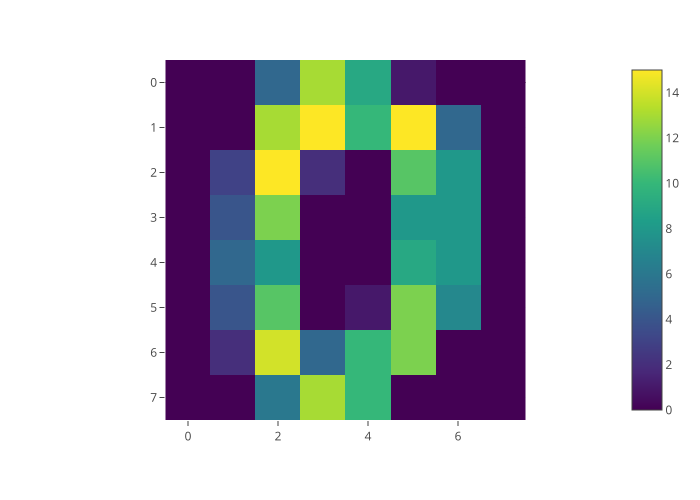

In [19]:
data = load_digits()
fig = px.imshow(data.images[0])
fig

In [7]:
numbers.data.shape

(1797, 64)

4. Now look at the documentation related to [imshow](https://plotly.com/python/imshow/) from plotly. Try to view a random number. Add as a title, the number this image corresponds to. Then try to view 10 random numbers in the dataset

In [ ]:
sigma = np.random.randint(0, 18, 1)

array([12], dtype=int32)

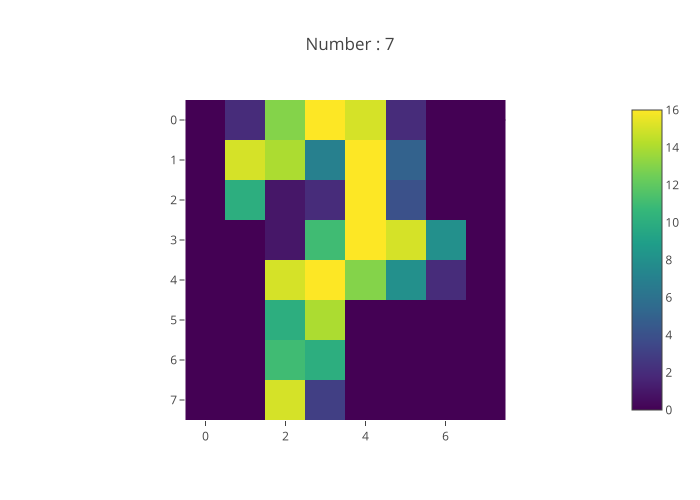

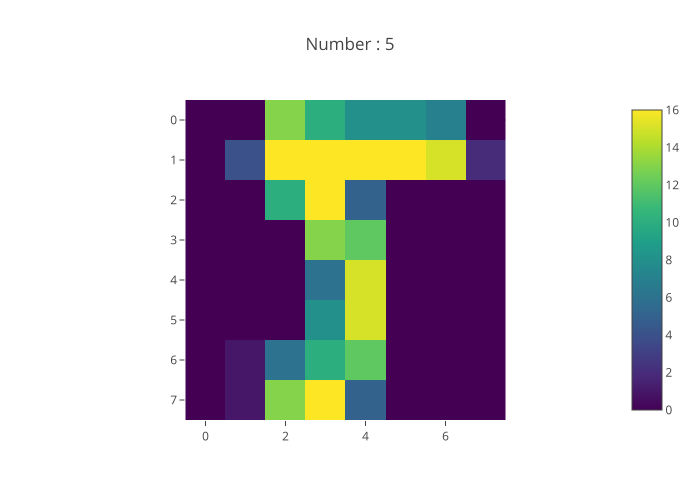

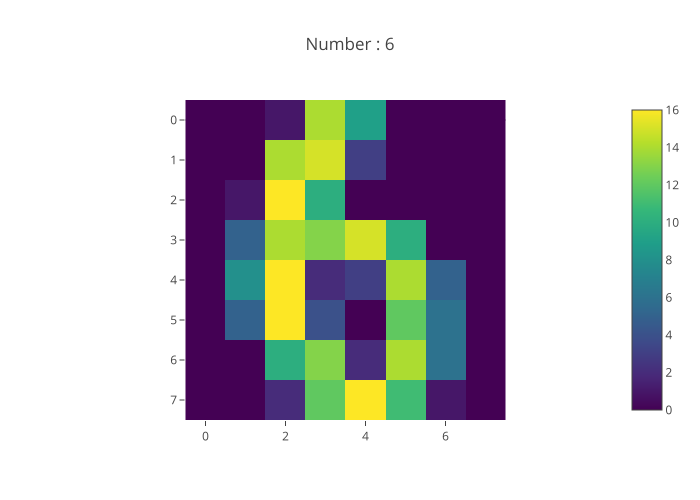

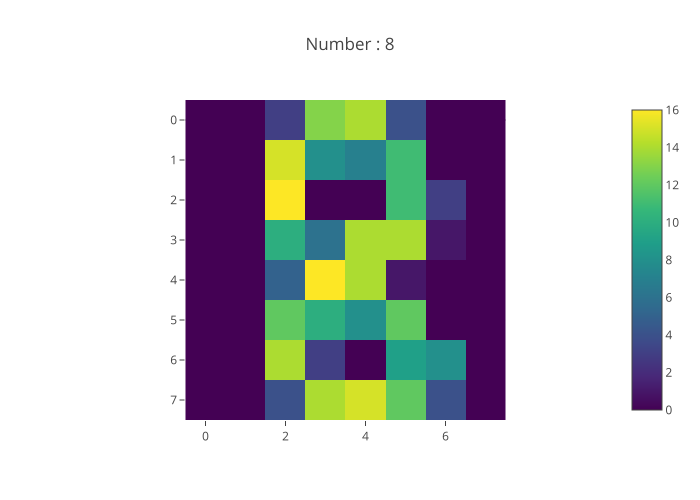

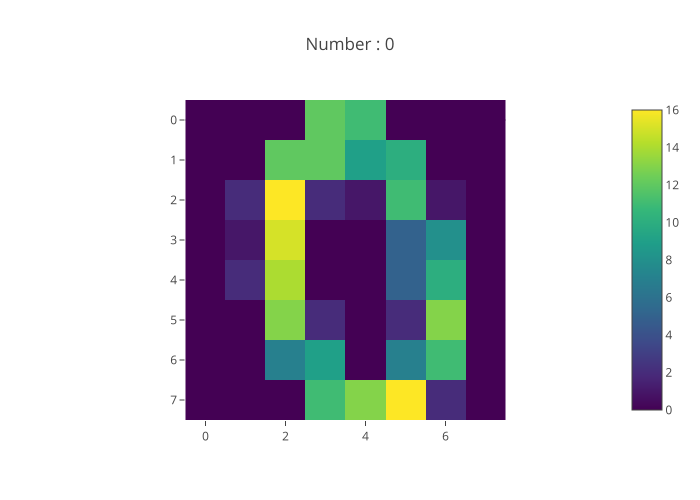

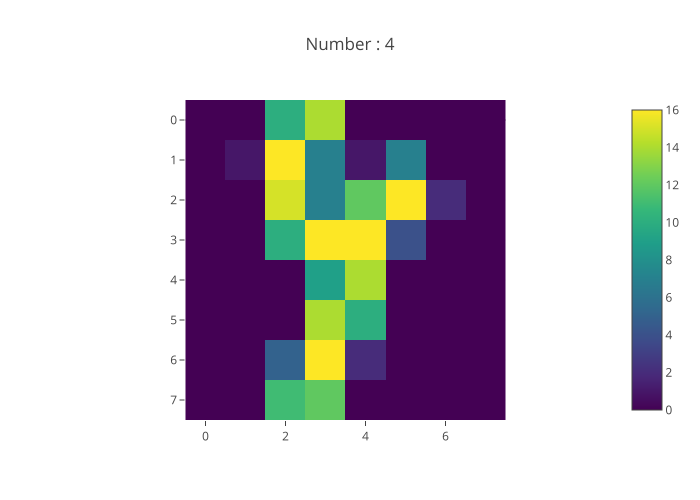

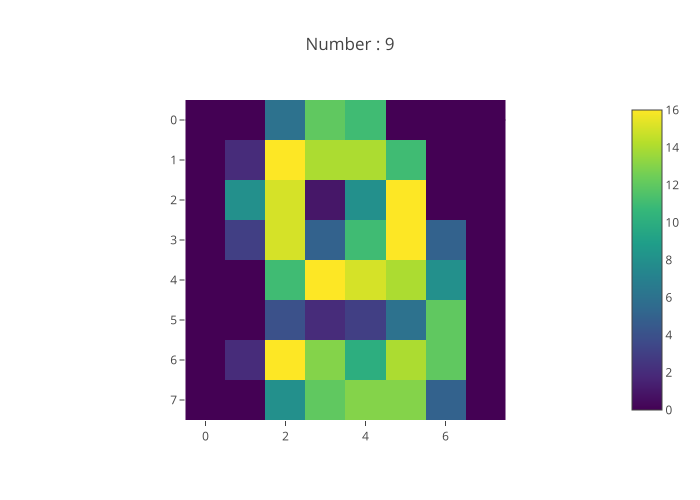

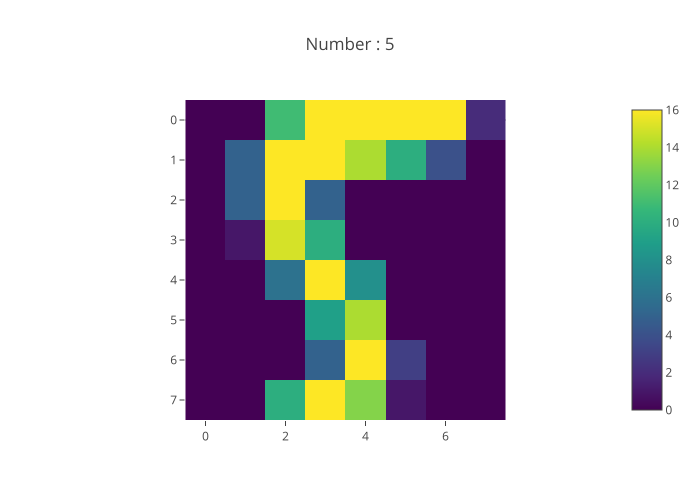

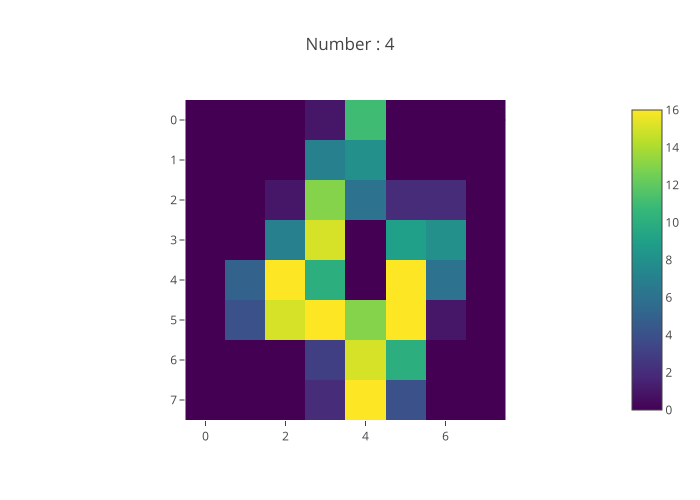

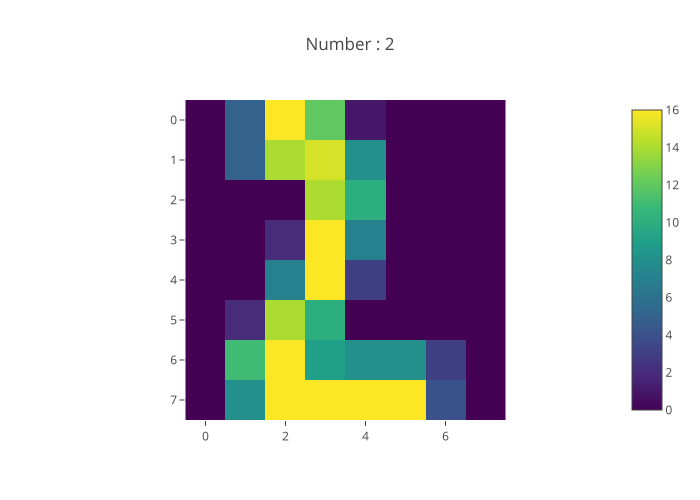

In [23]:
data = load_digits()
fig = px.imshow(data.images[0])
for i in range(10):
    sigma = np.random.randint(0, len(data.images))
    fig = px.imshow(data.images[sigma], title=f"Number : {data.target[sigma]}")
    fig.show()

5. We're going to apply the KMeans to our dataset, how many clusters do you think we're going to initialize the algorithm on?

---> 10 because we have 10 numbers in the dataset!

In [26]:
data.target_names

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

6. Create your KMeans algorithm with the right number of clusters

In [27]:
kmeans = KMeans(n_clusters=10, random_state=0)
kmeans

KMeans(n_clusters=10, random_state=0)

7. Let's evaluate our model, calculate the _accuracy_score_ of our predictions by importing the sklearn module. What do you conclude?

In [35]:
kmeans.fit(numbers)

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.



KMeans(n_clusters=10, random_state=0)

In [40]:
numbers.shape

(1797, 64)

In [39]:
kmeans.cluster_centers_.shape

(10, 64)

In [42]:
clusters = kmeans.fit_predict(numbers)
accuracy_score(target, clusters)

c:\Users\briic\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning:

KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.



0.01001669449081803

In [43]:
from sklearn.metrics import classification_report
print(classification_report(target,clusters))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       178
           1       0.00      0.00      0.00       182
           2       0.02      0.01      0.01       177
           3       0.00      0.00      0.00       183
           4       0.04      0.04      0.04       181
           5       0.01      0.03      0.02       182
           6       0.00      0.00      0.00       181
           7       0.00      0.00      0.00       179
           8       0.01      0.01      0.01       174
           9       0.01      0.01      0.01       180

    accuracy                           0.01      1797
   macro avg       0.01      0.01      0.01      1797
weighted avg       0.01      0.01      0.01      1797



8. Look at the coordinates of the centroids (cf. [cluster_center_](http://lijiancheng0614.github.io/scikit-learn/modules/generated/sklearn.cluster.KMeans.html))

In [44]:
kmeans.cluster_centers_

array([[ 0.00000000e+00,  9.22651934e-01,  1.01104972e+01,
         1.44751381e+01,  7.86740331e+00,  1.06077348e+00,
        -6.66133815e-16,  0.00000000e+00,  2.20994475e-02,
         5.21546961e+00,  1.36464088e+01,  1.25856354e+01,
         1.16464088e+01,  3.37016575e+00,  2.20994475e-02,
         0.00000000e+00,  1.10497238e-02,  4.49723757e+00,
         8.08839779e+00,  6.06629834e+00,  1.21049724e+01,
         3.71823204e+00,  3.86740331e-02, -6.93889390e-18,
         0.00000000e+00,  9.39226519e-01,  2.81767956e+00,
         7.00000000e+00,  1.25138122e+01,  2.76243094e+00,
         6.07734807e-02,  0.00000000e+00,  0.00000000e+00,
         4.41988950e-02,  1.59668508e+00,  9.86187845e+00,
         1.08342541e+01,  1.59668508e+00,  4.44089210e-16,
         0.00000000e+00,  0.00000000e+00,  2.43093923e-01,
         4.41988950e+00,  1.11325967e+01,  7.75138122e+00,
         2.60220994e+00,  9.39226519e-01,  1.10497238e-02,
         3.46944695e-18,  1.18232044e+00,  1.08950276e+0

9. Try to visualize each of the centroids and compare them with the different labels. What do you notice?

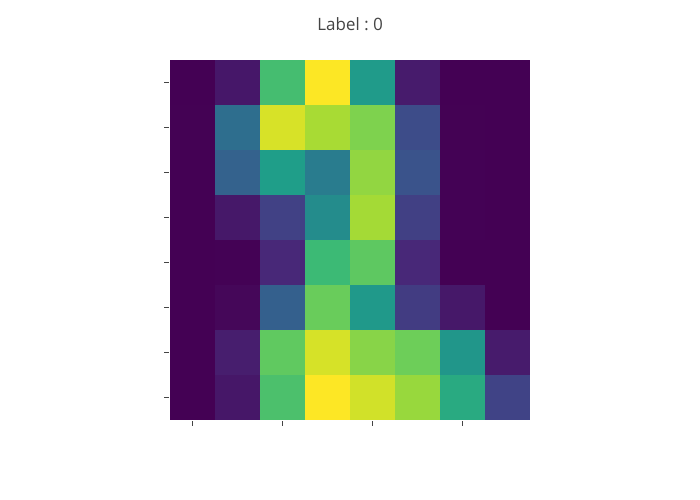

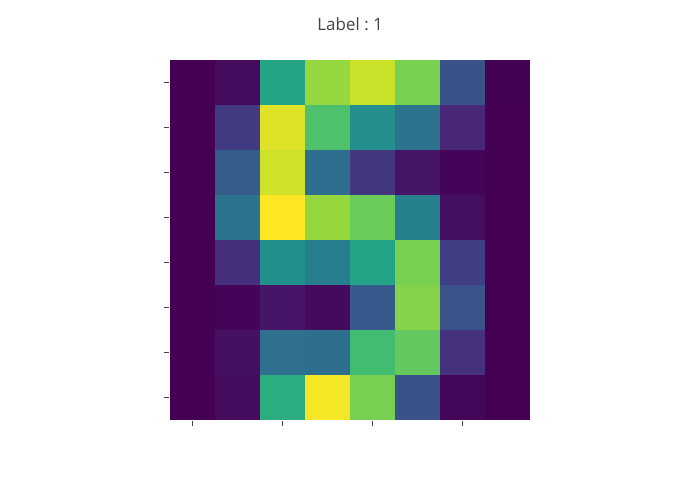

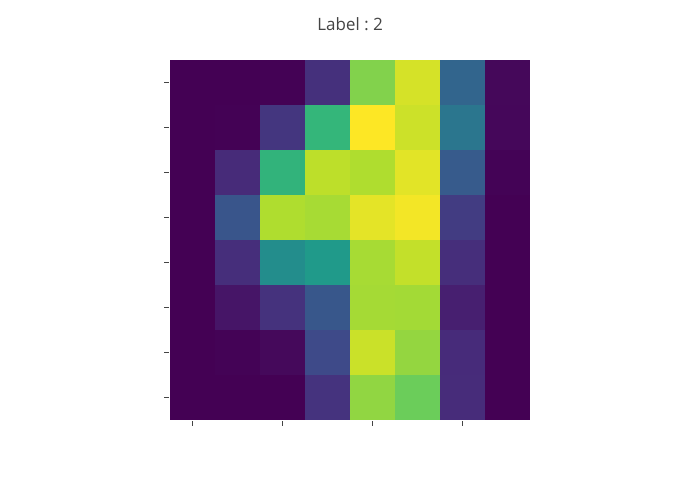

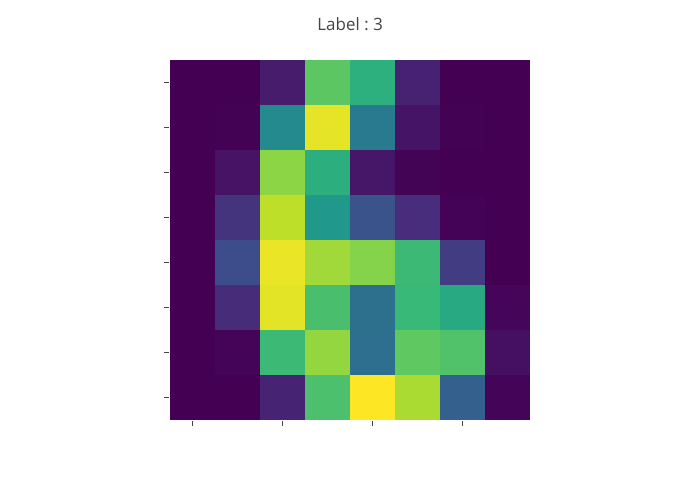

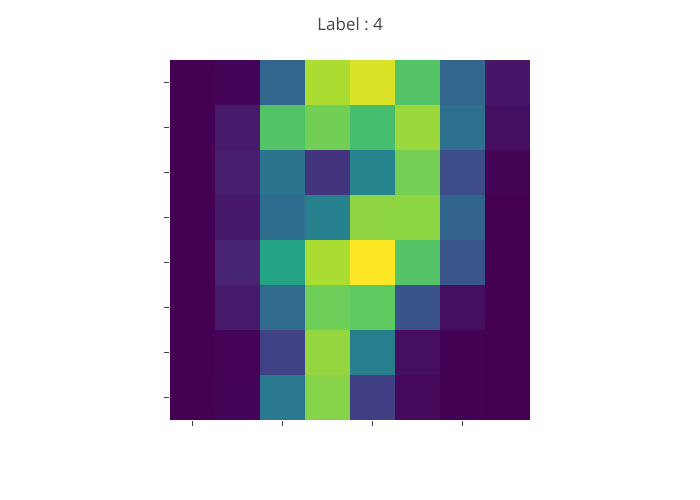

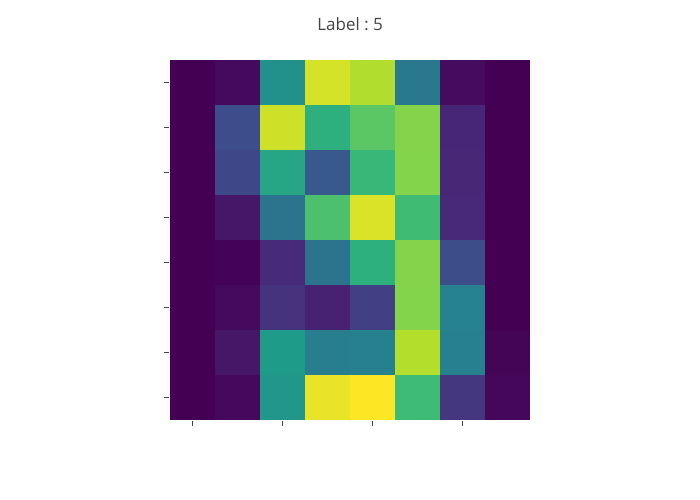

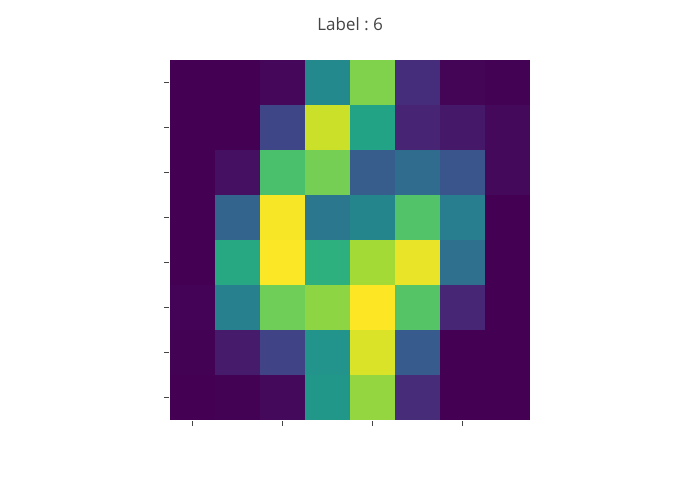

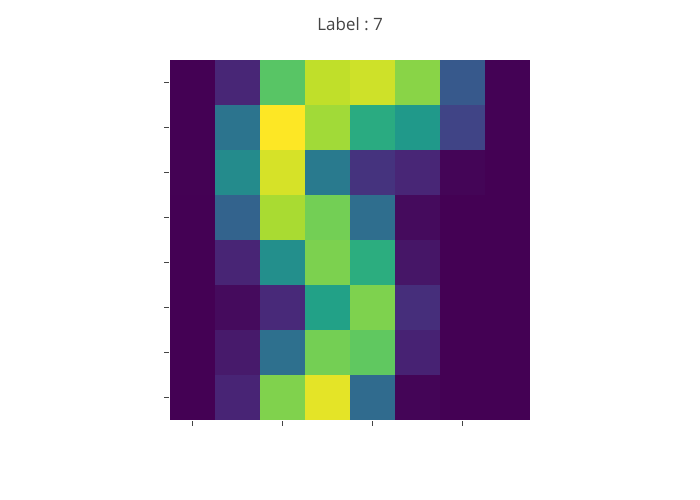

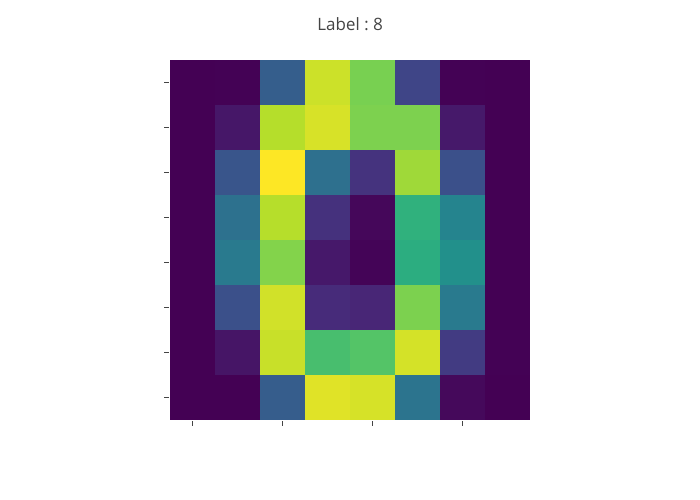

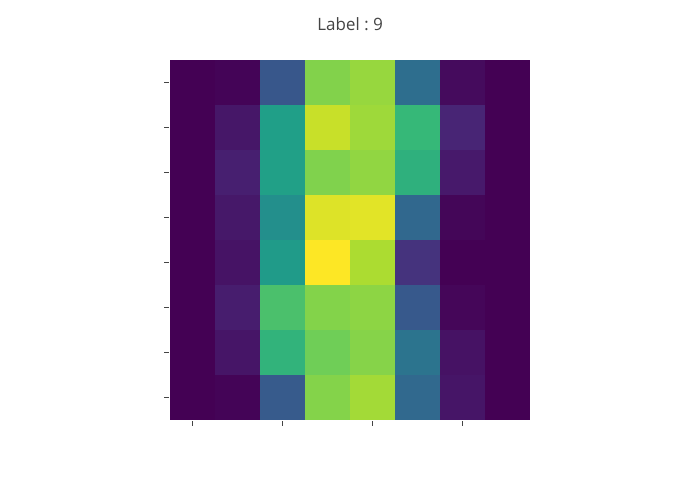

In [45]:
# Visualisation des centroïds
for i in range(10):
  fig = px.imshow(kmeans.cluster_centers_.reshape(10,8,8)[i])
  fig.update_xaxes(showticklabels=False)
  fig.update_yaxes(showticklabels=False)
  fig.update_layout(title = "Label : {}".format(i))
  fig.update_layout(coloraxis_showscale=False)
  fig.show()


----> Looks like good predictions! It just seems that centroids don't necessarily match the label.

10. We will try to match our cluster labels with the target values. Here are some clues:

    a. Identify the most frequent target value for observations in cluster 1.

4    167
5      2
0      2
Name: 0, dtype: int64

b. Programming a loop which allows to create a label vector which contains for each observation the target value corresponding to the cluster to which it belongs.

11. Re-evaluate your model. What is your new *accuracy_score*?

0.7918753478018921

12. Look at the numbers where our algorithm got it wrong the most via a confusion matrix...

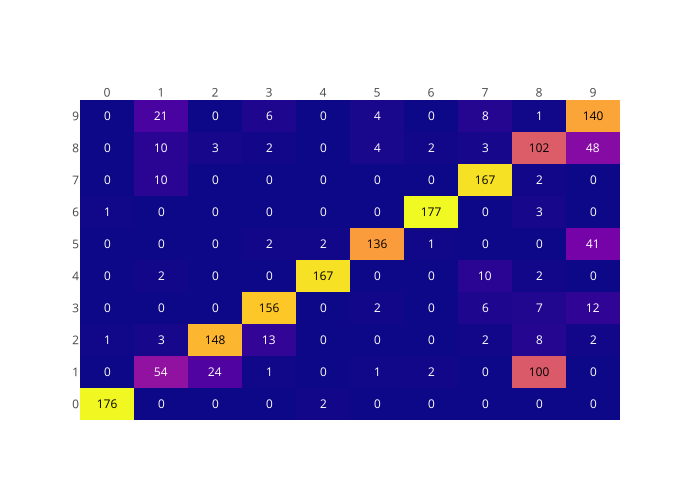